# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ektam9931/flyrank-ml-week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

This project asks whether historical SEO, search, traffic, and engagement signals can be used to predict observed changes in content clicks and help prioritize pages for review.

The decision this supports is content-review prioritization: when a team has limited resources, which pages should be reviewed first based on the model's predicted click change?

This is a decision-support problem rather than an attempt to prove Google's ranking algorithm or establish causal effects from refreshing content.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/ektam9931/flyrank-ml-week1/main/data/raw/content_refresh_anonymized.csv"
)

df.shape

(30000, 44)

In [28]:
df["click_change"] = (
    df["clicks_last_30d"] - df["clicks_prev_30d"]
)

drop_cols = [
    "content_id",
    "client_id",
    "click_change",
    "clicks_90d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "trend_direction",
    "trend_pct"
]

X = df.drop(columns=drop_cols)
y = df["click_change"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 37)
y shape: (30000,)


In [29]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train clients:", df.iloc[train_idx]["client_id"].nunique())
print("Test clients:", df.iloc[test_idx]["client_id"].nunique())

Train: (23837, 37)
Test: (6163, 37)
Train clients: 25
Test clients: 7


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [31]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events_90d',
                                                   'days_with_impressions',
                                                   'days_w...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Random Forest MAE:", mae)
print("Final Random Forest RMSE:", rmse)
print("Final Random Forest R²:", r2)

Final Random Forest MAE: 1.4778096527479636
Final Random Forest RMSE: 7.047829238314607
Final Random Forest R²: 0.5287835407834163


## 2. Data

The analysis uses the anonymized FlyRank ML Internship content-performance dataset. The dataset contains 30,000 content records and 44 original columns covering search, traffic, engagement, content, and performance signals.

The analysis uses the available content-level historical fields in the release. Client and content identifiers are retained only for grouping and anonymized recommendation output and are not used as predictive features.

The target is constructed from the available 30-day click windows. No client names, domains, URLs, private queries, credentials, or raw private exports are used in the public analysis.

In [33]:
print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Target-related columns:", [
    "clicks_last_30d",
    "clicks_prev_30d",
    "click_change"
])


Dataset shape: (30000, 45)
Number of columns: 45
Target-related columns: ['clicks_last_30d', 'clicks_prev_30d', 'click_change']


## 3. Methodology

The prediction target is click_change, defined as clicks_last_30d minus clicks_prev_30d.

The model uses historical search, traffic, engagement, and content characteristics available in the dataset. Content and client identifiers are not used as predictive features.

A zero-change baseline predicts no change in clicks for every held-out page. The main model is a Random Forest Regressor with 200 trees and a maximum depth of 12.

Validation uses a grouped train-test split by client_id, with 80% of observations for training and 20% for testing. Entire clients are kept in either the training or test group so that pages from the same client do not appear in both sets.

The final feature set excludes click_change, clicks_last_30d, clicks_prev_30d, clicks_90d, trend_direction, and trend_pct. These variables were excluded because they directly encode the target or overlap with the same click-change windows used to construct it.

Model performance is evaluated using MAE, RMSE, and R² on the same held-out client groups.

In [34]:
print("Target:", "click_change")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", df.iloc[train_idx]["client_id"].nunique())
print("Test clients:", df.iloc[test_idx]["client_id"].nunique())
print("Number of model features:", X.shape[1])


Target: click_change
Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Number of model features: 37


## 4. Results (vs baseline)

The leakage-audited Random Forest performs better than the zero-change baseline on the same held-out client groups.

The Random Forest achieved an MAE of 1.478, an RMSE of 7.048, and an R² of 0.529. The zero-change baseline achieved an MAE of 1.898, an RMSE of 10.267, and an R² approximately equal to zero.

These results indicate that the available historical features contain useful predictive signal for observed click change in the held-out client groups. The result is interpreted as predictive and directional rather than causal.

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Week-5 Random Forest",
        "Leakage-audited Random Forest",
        "Zero-change baseline"
    ],
    "MAE": [
        1.459440,
        1.477810,
        1.897939
    ],
    "RMSE": [
        6.776037,
        7.047829,
        10.267310
    ],
    "R2": [
        0.564427,
        0.528784,
        -0.000053
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Week-5 Random Forest,1.459440,6.776037,0.564427
1,Leakage-audited Random Forest,1.477810,7.047829,0.528784
2,Zero-change baseline,1.897939,10.267310,-0.000053


## 5. Limitations
This analysis has several important limitations. The dataset does not provide an observation date suitable for a chronological train-test split, so validation uses grouped client-level separation rather than a time-aware evaluation.

The model identifies predictive patterns in the available data but does not establish causal relationships between individual signals and click changes. In particular, feature importance should not be interpreted as proof that changing a feature will cause clicks to increase or decrease.

The model also performs less reliably on extreme click changes. Therefore, the ranked recommendations should be treated as decision-support priorities for human review rather than guarantees of future performance.

The analysis does not claim to prove, reproduce, or reverse-engineer Google's ranking algorithm.

In [36]:
print("Validation design: GroupShuffleSplit by client_id")
print("Time-aware split available:", False)
print("Causal claims:", False)
print("Google algorithm claims:", False)
print("Final model treated as decision-support:", True)


Validation design: GroupShuffleSplit by client_id
Time-aware split available: False
Causal claims: False
Google algorithm claims: False
Final model treated as decision-support: True


## 6. Ranked recommendations

The model output is converted into a ranked action list for content-review prioritization. Pages with larger predicted negative click changes receive higher review priority because the model identifies them as potential decline opportunities.

Pages with positive predicted click changes are treated as monitor/protect candidates rather than immediate refresh targets. Each recommendation includes a reason code describing the model-based signal behind the action.

These recommendations are directional decision-support outputs. They do not imply that refreshing a page will necessarily cause its performance to improve.

In [37]:
recommendations = df.iloc[test_idx][[
    "content_id",
    "client_id",
    "clicks_last_30d",
    "clicks_prev_30d"
]].copy()

recommendations["actual_click_change"] = y_test.values
recommendations["predicted_click_change"] = y_pred

recommendations["opportunity_score"] = np.maximum(
    -recommendations["predicted_click_change"],
    0
)

recommendations["reason_code"] = np.where(
    recommendations["predicted_click_change"] < 0,
    "PREDICTED_DECLINE",
    "PREDICTED_GROWTH"
)

recommendations["action"] = np.where(
    recommendations["predicted_click_change"] < 0,
    "Review / Refresh",
    "Monitor / Protect"
)

recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
)

top_recommendations = recommendations.head(20)

top_recommendations[
    [
        "content_id",
        "predicted_click_change",
        "opportunity_score",
        "reason_code",
        "action"
    ]
]

,content_id,predicted_click_change,opportunity_score,reason_code,action
21565,content_9532f197bbc8,-204.645000,204.645000,PREDICTED_DECLINE,Review / Refresh
2365,content_4a18c07e5357,-168.835000,168.835000,PREDICTED_DECLINE,Review / Refresh
21819,content_4c36c775b818,-165.838500,165.838500,PREDICTED_DECLINE,Review / Refresh
19645,content_3ad3a781fa91,-140.567350,140.567350,PREDICTED_DECLINE,Review / Refresh
26935,content_37106924f264,-122.375841,122.375841,PREDICTED_DECLINE,Review / Refresh
28335,content_007d1f134801,-90.235591,90.235591,PREDICTED_DECLINE,Review / Refresh
6653,content_5fe46e04994d,-66.023206,66.023206,PREDICTED_DECLINE,Review / Refresh
26413,content_bdd7c88a58ed,-64.552203,64.552203,PREDICTED_DECLINE,Review / Refresh
12064,content_4090f0acd977,-60.544833,60.544833,PREDICTED_DECLINE,Review / Refresh
26844,content_8c19996aa890,-48.943217,48.943217,PREDICTED_DECLINE,Review / Refresh


## 7. Artifacts the paper embeds
The final artifacts provide visual evidence for the model comparison, prediction behavior, feature importance, and ranked recommendations. The charts are generated directly from the final leakage-audited model and held-out evaluation set so that the paper can reproduce the reported results.

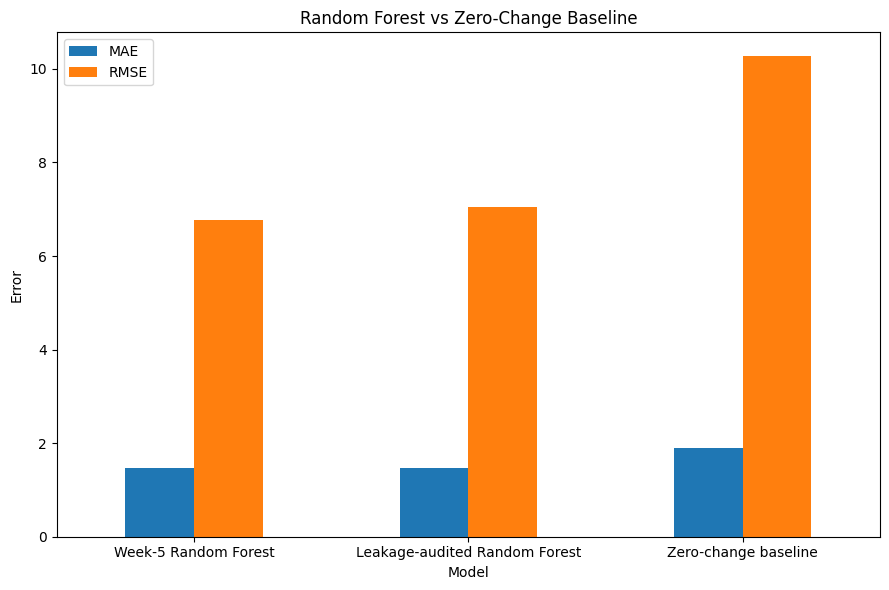

In [38]:
comparison_plot = comparison.set_index("Model")

comparison_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel("Error")
plt.title("Random Forest vs Zero-Change Baseline")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

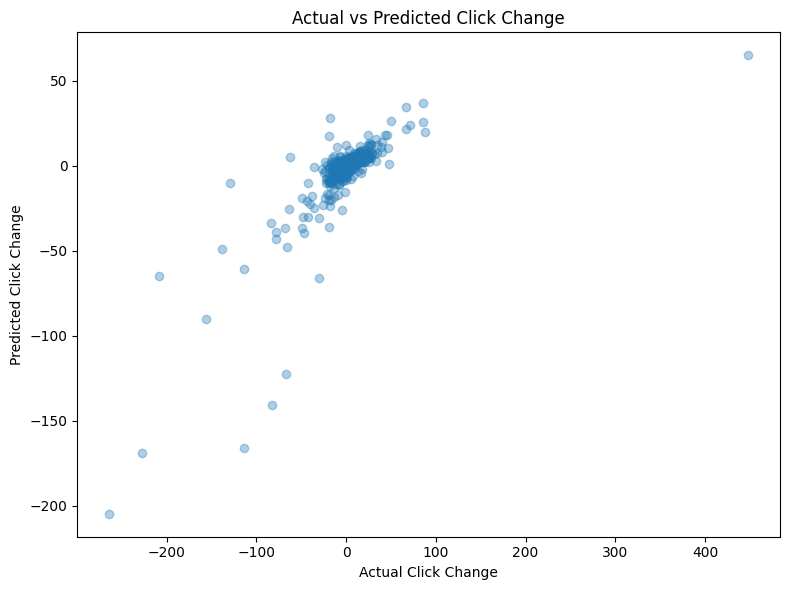

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.35
)

plt.xlabel("Actual Click Change")
plt.ylabel("Predicted Click Change")
plt.title("Actual vs Predicted Click Change")

plt.tight_layout()
plt.show()

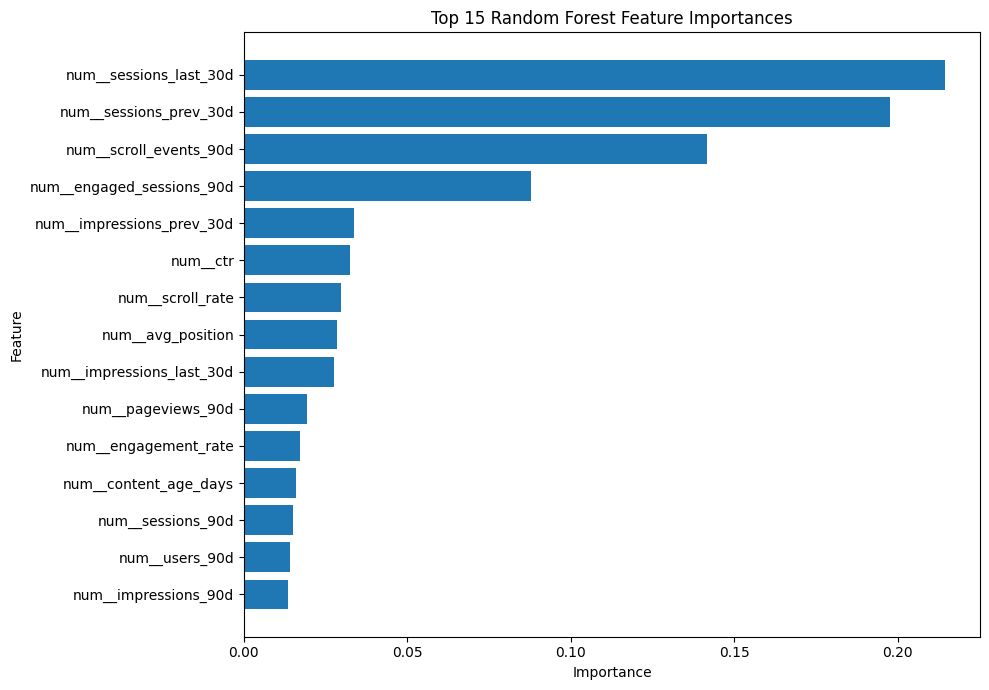

In [40]:
feature_importance = pd.DataFrame({
    "feature": model.named_steps["preprocessor"].get_feature_names_out(),
    "importance": model.named_steps["model"].feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [41]:
recommendations[
    [
        "content_id",
        "predicted_click_change",
        "opportunity_score",
        "reason_code",
        "action"
    ]
].to_csv(
    "ranked_content_recommendations.csv",
    index=False
)

print("Saved ranked_content_recommendations.csv")

Saved ranked_content_recommendations.csv


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.